In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from scipy.stats import pearsonr, spearmanr

In [2]:
summary_fba = pd.read_csv("fba_results.csv")
summary_fbawmc = pd.read_csv("fbawmc_average_a_summary.csv")
summary_fbawmc_specific = pd.read_csv("fbawmc_specific_a_summary.csv")

summary_fba = summary_fba.set_index("carbon_source")
summary_fbawmc = summary_fbawmc.set_index("carbon_source")
summary_fbawmc_specific = summary_fbawmc_specific.set_index("carbon_source")

experimental_growth = {
    "Glucose": 0.74,
    "Glycerol": 0.41,
    "Lactate": 0.38,
    "Maltose": 0.61,
    "Galactose": 0.51,
    "Acetate": 0.24
}
carbon_order = [
    "Glucose",
    "Maltose",
    "Galactose",
    "Glycerol",
    "Lactate",
    "Acetate"
]

In [3]:
comparison = pd.DataFrame(index=carbon_order)

# Experimental
comparison["Experimental"] = pd.Series(experimental_growth)

# FBA
comparison["FBA"] = summary_fba["growth_rate"]

# FBAwMC with average a
comparison["FBAwMC_average"] = summary_fbawmc["mean_growth"]
comparison["FBAwMC_average_SD"] = summary_fbawmc["std_growth"]

# FBAwMC with carbon-source-specific a
comparison["FBAwMC_specific"] = summary_fbawmc_specific["mean_growth"]
comparison["FBAwMC_specific_SD"] = summary_fbawmc_specific["std_growth"]

comparison

,Experimental,FBA,FBAwMC_average,FBAwMC_average_SD,FBAwMC_specific,FBAwMC_specific_SD
Glucose,0.74,0.921948,0.487404,0.067250,0.650400,0.083769
Maltose,0.61,0.921948,0.473787,0.063618,0.473085,0.064039
Galactose,0.51,0.898973,0.418989,0.056719,0.420418,0.053215
Glycerol,0.41,0.988361,0.470557,0.071239,0.335205,0.053298
Lactate,0.38,0.495026,0.361719,0.058049,0.360157,0.055601
Acetate,0.24,0.406953,0.229712,0.038489,0.230293,0.038358


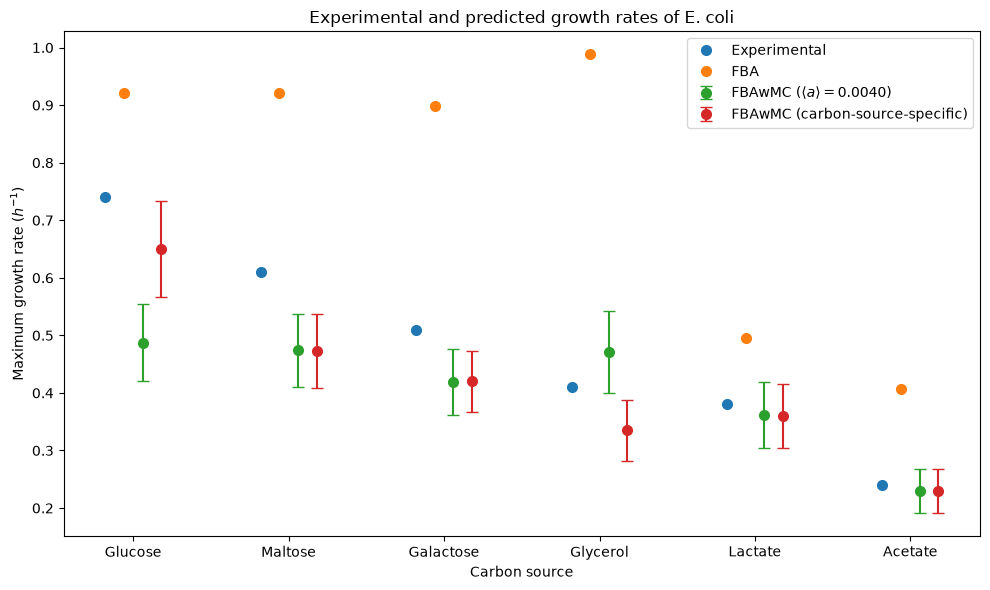

In [4]:

x = np.arange(len(carbon_order))

offsets = {
    "Experimental": -0.18,
    "FBA": -0.06,
    "FBAwMC_average": 0.06,
    "FBAwMC_specific": 0.18
}


plt.figure(figsize=(10, 6))

# Experimental
plt.errorbar(
    x + offsets["Experimental"],
    comparison.loc[carbon_order, "Experimental"],
    fmt="o",
    markersize=7,
    label="Experimental"
)


# FBA
plt.errorbar(
    x + offsets["FBA"],
    comparison.loc[carbon_order, "FBA"],
    fmt="o",
    markersize=7,
    label="FBA"
)


# FBAwMC - average crowding coefficient
plt.errorbar(
    x + offsets["FBAwMC_average"],
    comparison.loc[carbon_order, "FBAwMC_average"],
    yerr=comparison.loc[carbon_order, "FBAwMC_average_SD"],
    fmt="o",
    capsize=4,
    markersize=7,
    label=r"FBAwMC ($\langle a\rangle = 0.0040$)"
)


# FBAwMC - carbon-source-specific coefficients
plt.errorbar(
    x + offsets["FBAwMC_specific"],
    comparison.loc[carbon_order, "FBAwMC_specific"],
    yerr=comparison.loc[carbon_order, "FBAwMC_specific_SD"],
    fmt="o",
    capsize=4,
    markersize=7,
    label="FBAwMC (carbon-source-specific)"
)


plt.xticks(x, carbon_order)

plt.xlabel("Carbon source")
plt.ylabel(r"Maximum growth rate ($h^{-1}$)")

plt.title("Experimental and predicted growth rates of E. coli")

plt.legend()

plt.tight_layout()

plt.show()

In [6]:
y_exp = comparison.loc[carbon_order, "Experimental"]


models = {
    "Conventional FBA": comparison.loc[carbon_order, "FBA"],
    "FBAwMC average": comparison.loc[carbon_order, "FBAwMC_average"],
    "FBAwMC carbon-source-specific": comparison.loc[carbon_order, "FBAwMC_specific"]
}


metrics = []

for name, y_pred in models.items():

    y_pred = np.asarray(y_pred)
    y_exp_array = np.asarray(y_exp)

    r2 = r2_score(y_exp_array, y_pred)
    pearson_r, _ = pearsonr(y_exp_array, y_pred)
    spearman_rho, _ = spearmanr(y_exp_array, y_pred)
    rmse = np.sqrt(mean_squared_error(y_exp_array, y_pred))
    mae = mean_absolute_error(y_exp_array, y_pred)

    metrics.append({
        "Model": name,
        "R²": r2,
        "Pearson r": pearson_r,
        "Spearman rho": spearman_rho,
        "RMSE": rmse,
        "MAE": mae
    })


metrics_df = pd.DataFrame(metrics)

metrics_df

metrics_df.round(3).to_latex(
    "../results/statistical_metrics.tex",
    index=False,
    caption="Statistical comparison of conventional FBA and FBAwMC predictions with experimentally measured maximum growth rates.",
    label="tab:statistical_metrics"
)